In [1]:
import gcinfo
import pandas as pd
import matplotlib.pyplot as plt

gcinfo.list_resources(gcinfo.search_datasets(query='title:"Estimates of the number of non-permanent residents by type, quarterly"')["results"][0])


=== Estimates of the number of non-permanent residents by type, quarterly ===
ID: f8f711fa-6b75-4178-a60c-23093c071fc8
Org: Statistics Canada | Statistique Canada
Notes: This table provides quarterly estimates of the number of non-permanent residents by type for Canada, provinces and territories.<br>...
URL: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1710012101
Citation: Statistics Canada. Table 17-10-0121-01 Estimates of the number of non-permanent residents by type, quarterly
DOI:      https://doi.org/10.25318/1710012101-eng
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100121-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100121-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100121-SDMX.zip


In [2]:
df, df_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100121-eng.zip")

Using cached file: cache\17100121-eng.zip


In [3]:
df.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1361855,NaN,NaN,NaN,0
1,2021-07,Canada,2021A000011124,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927591,1.2,168206,NaN,NaN,NaN,0
2,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927592,1.3,94311,NaN,NaN,NaN,0
3,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927593,1.4,1485,NaN,NaN,NaN,0
4,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927594,1.5,4094,NaN,NaN,NaN,0


In [4]:
df["GEO"].unique()

array(['Canada', 'Newfoundland and Labrador', 'Prince Edward Island',
       'Nova Scotia', 'New Brunswick', 'Quebec', 'Ontario', 'Manitoba',
       'Saskatchewan', 'Alberta', 'British Columbia', 'Yukon',
       'Northwest Territories', 'Nunavut'], dtype=object)

In [5]:
df_region = df[df["GEO"].isin(['Newfoundland and Labrador', 'Prince Edward Island',
       'Nova Scotia', 'New Brunswick', 'Quebec', 'Ontario', 'Manitoba',
       'Saskatchewan', 'Alberta', 'British Columbia', 'Yukon',
       'Northwest Territories', 'Nunavut'])]
df_region["GEO"].unique()

array(['Newfoundland and Labrador', 'Prince Edward Island', 'Nova Scotia',
       'New Brunswick', 'Quebec', 'Ontario', 'Manitoba', 'Saskatchewan',
       'Alberta', 'British Columbia', 'Yukon', 'Northwest Territories',
       'Nunavut'], dtype=object)

In [6]:
df_region['REF_DATE'].unique()

array(['2021-07', '2021-10', '2022-01', '2022-04', '2022-07', '2022-10',
       '2023-01', '2023-04', '2023-07', '2023-10', '2024-01', '2024-04',
       '2024-07', '2024-10', '2025-01', '2025-04', '2025-07', '2025-10',
       '2026-01', '2026-04'], dtype=object)

In [7]:
df_region_2026_04 = df_region[df_region['REF_DATE'].apply(lambda x: x.startswith("2026-04"))]
df_region_2026_04.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
2937,2026-04,Newfoundland and Labrador,2021A000210,"Total, non-permanent residents",Persons,249,units,0,v1566927601,2.1,15933,NaN,NaN,NaN,0
2938,2026-04,Newfoundland and Labrador,2021A000210,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927602,2.2,841,NaN,NaN,NaN,0
2939,2026-04,Newfoundland and Labrador,2021A000210,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927603,2.3,580,NaN,NaN,NaN,0
2940,2026-04,Newfoundland and Labrador,2021A000210,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927604,2.4,19,NaN,NaN,NaN,0
2941,2026-04,Newfoundland and Labrador,2021A000210,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927605,2.5,42,NaN,NaN,NaN,0


In [8]:
df_region_2026_04_total_asylum = df_region_2026_04[df_region_2026_04["Non-permanent resident types"] == "Total, asylum claimants, protected persons and related groups"]
df_region_2026_04_total_asylum

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
2938,2026-04,Newfoundland and Labrador,2021A000210,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927602,2.2,841,NaN,NaN,NaN,0
2949,2026-04,Prince Edward Island,2021A000211,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927613,3.2,186,NaN,NaN,NaN,0
2960,2026-04,Nova Scotia,2021A000212,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927624,4.2,1424,NaN,NaN,NaN,0
2971,2026-04,New Brunswick,2021A000213,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927635,5.2,1532,NaN,NaN,NaN,0
2982,2026-04,Quebec,2021A000224,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927646,6.2,190300,NaN,NaN,NaN,0
2993,2026-04,Ontario,2021A000235,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927657,7.2,253643,NaN,NaN,NaN,0
3004,2026-04,Manitoba,2021A000246,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927668,8.2,5432,NaN,NaN,NaN,0
3015,2026-04,Saskatchewan,2021A000247,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927679,9.2,2039,NaN,NaN,NaN,0
3026,2026-04,Alberta,2021A000248,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927690,10.2,32677,NaN,NaN,NaN,0
3037,2026-04,British Columbia,2021A000259,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927701,11.2,37087,NaN,NaN,NaN,0


In [9]:
df_region_2026_04_total_asylum.shape

(13, 15)

In [10]:
df_region_2026_04_total_asylum[["GEO", "VALUE"]]

,GEO,VALUE
2938,Newfoundland and Labrador,841
2949,Prince Edward Island,186
2960,Nova Scotia,1424
2971,New Brunswick,1532
2982,Quebec,190300
2993,Ontario,253643
3004,Manitoba,5432
3015,Saskatchewan,2039
3026,Alberta,32677
3037,British Columbia,37087


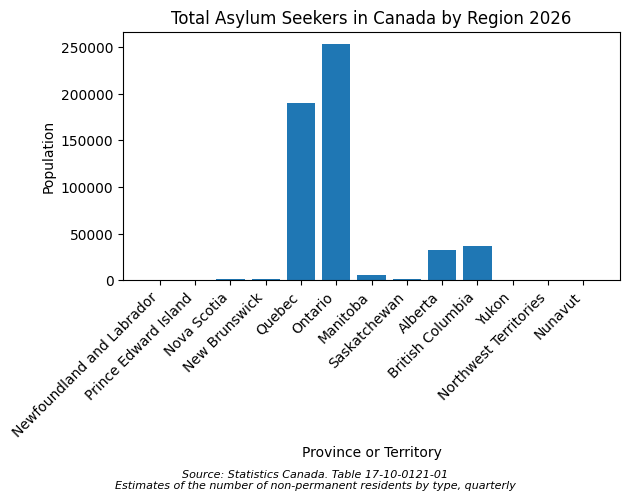

In [11]:
fig, ax = plt.subplots()

ax.bar(df_region_2026_04_total_asylum["GEO"], df_region_2026_04_total_asylum["VALUE"])

ax.set_title("Total Asylum Seekers in Canada by Region 2026")
ax.set_xlabel("Province or Territory")
ax.set_ylabel("Population")

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5, -0.03,
    "Source: Statistics Canada. Table 17-10-0121-01\nEstimates of the number of non-permanent residents by type, quarterly",
    ha="center",
    fontsize=8,
    style="italic"
)

plt.tight_layout()
plt.show()

In [12]:
(253643 / 14000000) * 100

1.8117357142857142

In [13]:
(190300 / 8000000) * 100

2.37875

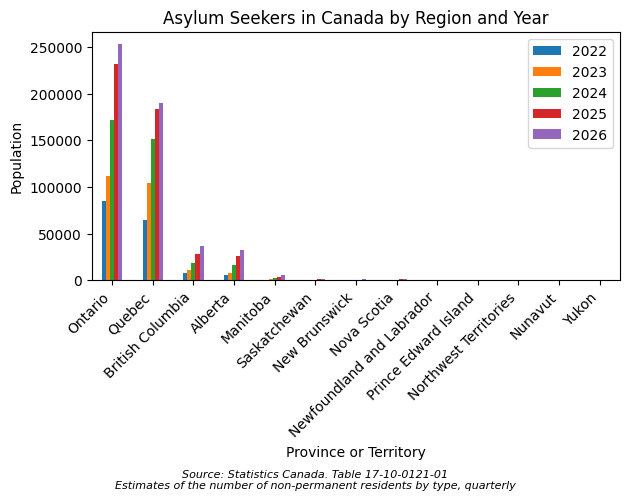

In [14]:
df_asylum = df_region[
    df_region["Non-permanent resident types"]
    == "Total, asylum claimants, protected persons and related groups"
].copy()

df_asylum_apr = df_asylum[df_asylum["REF_DATE"].str.endswith("-04")].copy()
df_asylum_apr["YEAR"] = df_asylum_apr["REF_DATE"].str[:4]

geo_order = (
    df_asylum_apr[df_asylum_apr["YEAR"] == "2026"]
    .sort_values("VALUE", ascending=False)["GEO"]
    .tolist()
)

pivot = (
    df_asylum_apr.pivot(index="GEO", columns="YEAR", values="VALUE")
    .reindex(geo_order)
)

fig, ax = plt.subplots()

pivot.plot(kind="bar", ax=ax, legend=False)

ax.set_title("Asylum Seekers in Canada by Region and Year")
ax.set_xlabel("Province or Territory")
ax.set_ylabel("Population")

ax.legend(
    title=None,
    loc="upper right",
    frameon=True,
)

plt.xticks(rotation=45, ha="right")
plt.subplots_adjust(bottom=0.3)

plt.figtext(
    0.5,
    -0.03,
    "Source: Statistics Canada. Table 17-10-0121-01\nEstimates of the number of non-permanent residents by type, quarterly",
    ha="center",
    fontsize=8,
    style="italic",
)

plt.tight_layout()
plt.show()